# 03 - Incorporación incremental de años (Ejercicios 5 y 8)

Valida que los archivos de nuevos años descargados con `scripts/download_data.py` quedan disponibles
en las mismas vistas (`sql/00_vistas.sql`) **sin modificar ninguna consulta**.

```bash
python scripts/download_data.py            # descarga solo lo que falta
python scripts/verify_data.py              # integridad y completitud
```

In [1]:
import sys
sys.path.insert(0, '../scripts')
import lab_db
import matplotlib.pyplot as plt
import pandas as pd

con = lab_db.conectar()
def q(nombre, archivo):
    c = lab_db.consulta(nombre, archivo)
    df, s = lab_db.ejecutar(con, c.sql)
    print(f"[{nombre}] {c.meta.get('objetivo','')}  ({s:.2f} s)")
    return df

## Ejercicio 5 - Validación de 2024

In [2]:
V24 = '../sql/05_validacion_2024.sql'
q('q5_01_archivos_por_anio', V24)

[q5_01_archivos_por_anio] Verificar que existan 12 archivos por tipo para 2024 y que los de 2026 se conserven (5.2, 5.5).  (0.00 s)


,taxi_type,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,green,2025,12,2025-01,2025-12
2,green,2026,8,2026-01,2026-08
3,yellow,2024,12,2024-01,2024-12
4,yellow,2025,12,2025-01,2025-12
5,yellow,2026,8,2026-01,2026-08


In [3]:
q('q5_02_registros_metadatos_vs_escaneo', V24)

[q5_02_registros_metadatos_vs_escaneo] Comprobar que el numero de filas en los metadatos coincide con lo que leen las vistas, por anio (5.5).  (0.06 s)


,taxi_type,anio,filas_metadatos,filas_vista_trips,coincide
0,yellow,2024,41169720.0,41169720,True
1,yellow,2025,48722602.0,48722602,True
2,yellow,2026,29703355.0,29703355,True
3,green,2024,660218.0,660218,True
4,green,2025,591375.0,591375,True
5,green,2026,337114.0,337114,True


In [4]:
e = q('q5_03_diferencias_esquema_por_anio', V24)
e[e.isna().any(axis=1)]

[q5_03_diferencias_esquema_por_anio] Identificar columnas que existen en un anio y no en otro (5.6, 5.7).  (0.02 s)


,taxi_type,columna,2024,2025,2026
5,yellow,cbd_congestion_fee,<NA>,12,8
13,yellow,request_source,<NA>,<NA>,3
25,green,cbd_congestion_fee,<NA>,12,8
36,green,request_source,<NA>,<NA>,3


In [5]:
q('q5_04_cobertura_mensual', V24)

[q5_04_cobertura_mensual] Consultar conjuntamente 2024 y 2026 y verificar la cobertura mes a mes desde la vista unificada (5.6).  (0.11 s)


,taxi_type,file_year,m01,m02,m03,m04,m05,m06,m07,m08,m09,m10,m11,m12
0,yellow,2024,2964624.0,3007526.0,3582628.0,3514289.0,3723833.0,3539193.0,3076903.0,2979183.0,3633030.0,3833771.0,3646369.0,3668371.0
1,yellow,2025,3475226.0,3577543.0,4145257.0,3970553.0,4591845.0,4322960.0,3898963.0,3574091.0,4251015.0,4428699.0,4181444.0,4305006.0
2,yellow,2026,3724889.0,3399866.0,3952451.0,3831240.0,4090836.0,3837248.0,3530109.0,3336716.0,NaN,NaN,NaN,NaN
3,green,2024,56551.0,53577.0,57457.0,56471.0,61003.0,54748.0,51837.0,51771.0,54440.0,56147.0,52222.0,53994.0
4,green,2025,48326.0,46621.0,51539.0,52132.0,55399.0,49390.0,48205.0,46306.0,48893.0,49416.0,46912.0,48236.0
5,green,2026,40272.0,37373.0,44208.0,44238.0,44921.0,44163.0,41252.0,40687.0,NaN,NaN,NaN,NaN


In [6]:
q('q5_05_nulos_columnas_nuevas', V24)

[q5_05_nulos_columnas_nuevas] Medir los nulos de las columnas que dependen del anio para decidir como tratarlas (5.7).  (0.27 s)


,taxi_type,anio,viajes,pct_cbd_nulo,pct_pasajeros_nulo,pct_pago_desconocido
0,yellow,2024,41169720,100.00,9.94,9.94
1,yellow,2025,48722602,0.00,23.83,23.83
2,yellow,2026,29703355,0.00,25.98,25.98
3,green,2024,660218,100.00,3.68,3.68
4,green,2025,591375,0.65,8.43,8.43
5,green,2026,337114,0.00,14.47,14.47


In [7]:
q('q5_06_calidad_por_anio', V24)

[q5_06_calidad_por_anio] Verificar que las reglas de limpieza (trips_clean) funcionan igual para 2024 (5.7).  (1.76 s)


,taxi_type,anio,registros,registros_limpios,pct_conservado
0,yellow,2024,41169720,39114044,95.01
1,yellow,2025,48722602,43570037,89.42
2,yellow,2026,29703355,27884915,93.88
3,green,2024,660218,606588,91.88
4,green,2025,591375,542323,91.71
5,green,2026,337114,309437,91.79


In [8]:
q('q5_07_rango_fechas', V24)

[q5_07_rango_fechas] Confirmar que, tras la limpieza, cada anio solo contiene fechas de su propio periodo (5.5).  (1.75 s)


,taxi_type,anio,primer_pickup,ultimo_pickup,dias_con_viajes
0,yellow,2024,2024-01-01 00:00:00,2024-12-31 23:59:58,366
1,yellow,2025,2025-01-01 00:00:00,2025-12-31 23:59:57,365
2,yellow,2026,2026-01-01 00:00:00,2026-08-31 23:59:59,243
3,green,2024,2024-01-01 00:03:57,2024-12-31 23:56:49,366
4,green,2025,2025-01-01 00:01:11,2025-12-31 23:59:09,365
5,green,2026,2026-01-01 00:03:27,2026-08-31 23:58:28,243


In [9]:
q('q5_08_comparacion_mismo_periodo', V24)

[q5_08_comparacion_mismo_periodo] Comparar 2024 vs 2026 en el mismo periodo (enero-agosto) para que la comparacion sea justa (5.6, 5.7).  (1.81 s)


,taxi_type,anio,viajes_ene_ago,viajes_por_dia,distancia_prom,duracion_prom,total_prom,tarifa_prom
0,yellow,2024,25127229,102980.0,3.44,16.5,28.33,19.53
1,yellow,2025,28305202,116482.0,3.48,16.5,28.32,19.55
2,yellow,2026,27884915,114753.0,3.55,17.7,30.18,21.22
3,green,2024,407649,1671.0,2.95,14.6,23.74,17.72
4,green,2025,362901,1493.0,3.13,15.5,24.83,17.96
5,green,2026,309437,1273.0,3.34,17.1,25.32,16.90


### Las consultas del Ejercicio 4 funcionan sin cambios sobre todos los años

[q4_01_viajes_por_mes] Contar viajes, ingresos y viajes promedio por dia para cada mes y tipo.  (0.24 s)


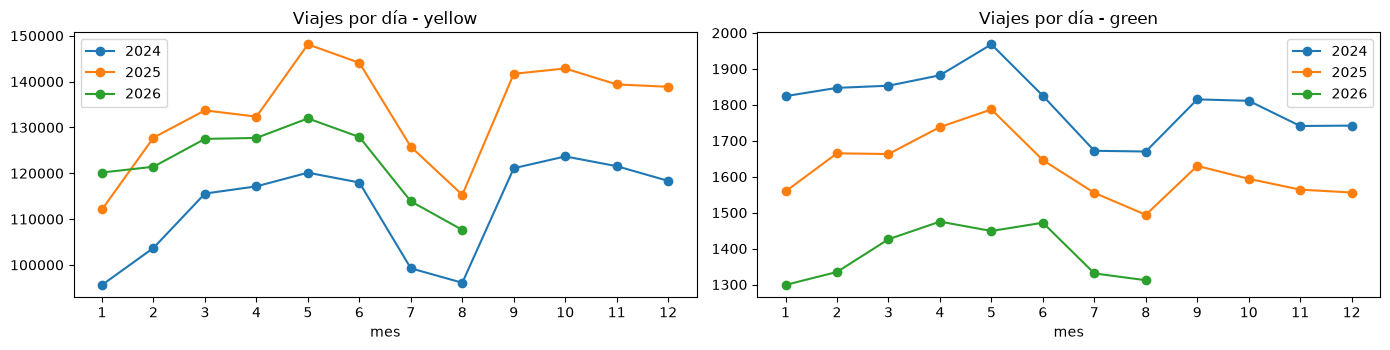

In [10]:
mes = q('q4_01_viajes_por_mes', '../sql/04_eda.sql')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
for ax, tipo in zip(axes, ['yellow', 'green']):
    for anio, d in mes[mes.taxi_type == tipo].groupby('anio'):
        ax.plot(d.mes, d.viajes_por_dia, marker='o', label=str(anio))
    ax.set_title(f'Viajes por día - {tipo}'); ax.set_xlabel('mes'); ax.set_xticks(range(1, 13)); ax.legend()
plt.tight_layout(); plt.show()

## Ejercicio 8 - Validación de 2025 (tres años)

In [11]:
V25 = '../sql/08_validacion_2025.sql'
q('q8_01_archivos_por_anio', V25)

[q8_01_archivos_por_anio] Verificar que existen los archivos de 2024, 2025 y 2026 para ambos tipos de taxi (8.1, 8.2).  (0.00 s)


,taxi_type,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,green,2025,12,2025-01,2025-12
2,green,2026,8,2026-01,2026-08
3,yellow,2024,12,2024-01,2024-12
4,yellow,2025,12,2025-01,2025-12
5,yellow,2026,8,2026-01,2026-08


In [12]:
q('q8_02_registros_metadatos_vs_escaneo', V25)

[q8_02_registros_metadatos_vs_escaneo] Comprobar que las vistas leen todas las filas de cada anio (8.3).  (0.07 s)


,taxi_type,anio,filas_metadatos,filas_vista_trips,coincide
0,yellow,2024,41169720.0,41169720,True
1,yellow,2025,48722602.0,48722602,True
2,yellow,2026,29703355.0,29703355,True
3,green,2024,660218.0,660218,True
4,green,2025,591375.0,591375,True
5,green,2026,337114.0,337114,True


In [13]:
q('q8_03_cobertura_mensual', V25)

[q8_03_cobertura_mensual] Consultar conjuntamente los 3 anios y ver la cobertura mes a mes (8.3).  (0.12 s)


,taxi_type,file_year,m01,m02,m03,m04,m05,m06,m07,m08,m09,m10,m11,m12
0,yellow,2024,2964624.0,3007526.0,3582628.0,3514289.0,3723833.0,3539193.0,3076903.0,2979183.0,3633030.0,3833771.0,3646369.0,3668371.0
1,yellow,2025,3475226.0,3577543.0,4145257.0,3970553.0,4591845.0,4322960.0,3898963.0,3574091.0,4251015.0,4428699.0,4181444.0,4305006.0
2,yellow,2026,3724889.0,3399866.0,3952451.0,3831240.0,4090836.0,3837248.0,3530109.0,3336716.0,NaN,NaN,NaN,NaN
3,green,2024,56551.0,53577.0,57457.0,56471.0,61003.0,54748.0,51837.0,51771.0,54440.0,56147.0,52222.0,53994.0
4,green,2025,48326.0,46621.0,51539.0,52132.0,55399.0,49390.0,48205.0,46306.0,48893.0,49416.0,46912.0,48236.0
5,green,2026,40272.0,37373.0,44208.0,44238.0,44921.0,44163.0,41252.0,40687.0,NaN,NaN,NaN,NaN


In [14]:
q('q8_04_columnas_por_anio', V25)

[q8_04_columnas_por_anio] Ver como evoluciona el esquema en los 3 anios (8.3).  (0.02 s)


,taxi_type,columna,2024,2025,2026
0,yellow,Airport_fee,12,12,8
1,yellow,DOLocationID,12,12,8
2,yellow,PULocationID,12,12,8
3,yellow,RatecodeID,12,12,8
4,yellow,VendorID,12,12,8
5,yellow,cbd_congestion_fee,<NA>,12,8
6,yellow,congestion_surcharge,12,12,8
7,yellow,extra,12,12,8
8,yellow,fare_amount,12,12,8
9,yellow,improvement_surcharge,12,12,8


In [15]:
q('q8_05_calidad_por_anio', V25)

[q8_05_calidad_por_anio] Verificar que las reglas de limpieza se comportan igual en los 3 anios (8.3).  (1.73 s)


,taxi_type,anio,registros,registros_limpios,pct_conservado,sin_taximetro_pct
0,yellow,2024,41169720,39114044,95.01,9.94
1,yellow,2025,48722602,43570037,89.42,23.83
2,yellow,2026,29703355,27884915,93.88,25.98
3,green,2024,660218,606588,91.88,3.68
4,green,2025,591375,542323,91.71,8.43
5,green,2026,337114,309437,91.79,14.47
